# SpaceX Falcon 9 : First Stage Landing Prediction


### Project Overview :
SpaceX has changed the space industry by offering **Falcon 9** launches for around `$62 million`. Other companies charge over `$165 million` per launch! 

The secret to this low price is "reusability".
SpaceX lands the first stage of the rocket and uses it again for future missions.



### Our Goal :
In this project, we want to build a machine learning model to predict if the first stage will land successfully.

If we can predict the landing, we can estimate the actual cost of a mission. This is very valuable for any company trying to compete in the space market.

### Successful Booster Recoveries :

<div style="display:flex; justify-content:center; gap:20px; width:100%;">
  <img src="../images/successful.landing.1.gif" style="width:48%; height:260px; object-fit:cover;">
  <img src="../images/successful.landing.2.gif" style="width:48%; height:260px; object-fit:cover;">
</div>

### Failed Landing Attempts :

<div style="display:flex; justify-content:center; gap:20px; width:100%;">
  <img src="../images/failed.landing.1.gif" style="width:48%; height:260px; object-fit:cover;">
  <img src="../images/failed.landing.2.gif" style="width:48%; height:260px; object-fit:cover;">
</div>



<br>

### Loading Essential Libraries and Custom Functions :


In this section, we load all the essential Python libraries needed for data analysis and machine learning.

These tools will help us process SpaceX data and build our prediction models.

In [282]:
# 1. Tools for handling data (Tables and Math)
import pandas as pd
import numpy as np

# 2. Tools for drawing charts and pictures
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Machine Learning Brains 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# 4. Tools to help train and test 
from sklearn import preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, RocCurveDisplay

# 5. Tool to save our finished model
import pickle

<br>

### Visualizing Model Performance : Confusion Matrix Function

In [283]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

     # Calculate the matrix values
    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()

     # Create the visualization
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

     # Adding titles and labels
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed'])

<br>

### load the dataframe

In [284]:
data = pd.read_csv('D:\project/dataset_falcon9.csv')
# shows the first 10 rows of a DataFrame.
data.head(10)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,6/4/2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B0003,-80.577366,28.561857,0
1,2,5/22/2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B0005,-80.577366,28.561857,0
2,3,3/1/2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B0007,-80.577366,28.561857,0
3,4,9/29/2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1,0,B1003,-120.610829,34.632093,0
4,5,12/3/2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B1004,-80.577366,28.561857,0
5,6,1/6/2014,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B1005,-80.577366,28.561857,0
6,7,4/18/2014,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1,0,B1006,-80.577366,28.561857,1
7,8,7/14/2014,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1,0,B1007,-80.577366,28.561857,1
8,9,8/5/2014,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B1008,-80.577366,28.561857,0
9,10,9/7/2014,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B1011,-80.577366,28.561857,0



<br>


### Data Exploration and Understanding

In this section, we analyze the structure of our SpaceX dataset to understand the type of information we have and identify any missing values.

In [285]:
# data.info() shows us a summary of the columns, their data types, and missing values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90 non-null     object 
 6   Outcome         90 non-null     object 
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     object 
 12  Block           90 non-null     int64  
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     object 
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
 17  Class           90 non-null     int64

<br>

### Key Observation: Missing Data in LandingPad
By looking at the summary, we see that the **LandingPad** column has only **64** non-null values out of **90** total entries. 

### Data Quality Check :
Let's check if we have any missing information in our dataset.

In [286]:
# Checking for missing values in each column
data.isnull().sum()

FlightNumber       0
Date               0
BoosterVersion     0
PayloadMass        0
Orbit              0
LaunchSite         0
Outcome            0
Flights            0
GridFins           0
Reused             0
Legs               0
LandingPad        26
Block              0
ReusedCount        0
Serial             0
Longitude          0
Latitude           0
Class              0
dtype: int64

This means there are **26** missing values. This is expected because not every SpaceX launch attempts a landing on a specific pad; some boosters are intentionally expended or lost during the mission.

<br>

### 📊 Success vs. Failure Distribution
We are splitting our dataset to analyze the characteristics of successful landings compared to failed missions.
<br>

In [287]:
# Create dataframes for success and failure cases
data_success = data[data['Class'] == 1]
data_fail = data[data['Class'] != 1]

# Verify the unique values in the Class column
print("Success unique values :", data_success['Class'].unique())
print("Failure unique values :", data_fail['Class'].unique())

Success unique values : [1]
Failure unique values : [0]


In [288]:
# Checking the number of rows and columns for each group
print("Success shape :", data_success.shape)
print("Failure shape :", data_fail.shape)

Success shape : (60, 18)
Failure shape : (30, 18)


In [289]:
data_success 

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
6,7,4/18/2014,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1,0,B1006,-80.577366,28.561857,1
7,8,7/14/2014,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1,0,B1007,-80.577366,28.561857,1
12,13,2/11/2015,Falcon 9,570.000000,ES-L1,CCAFS SLC 40,True Ocean,1,True,False,True,NaN,1,0,B1013,-80.577366,28.561857,1
16,17,12/22/2015,Falcon 9,2034.000000,LEO,CCAFS SLC 40,True RTLS,1,True,False,True,5e9e3032383ecb267a34e7c7,1,0,B1019,-80.577366,28.561857,1
19,20,4/8/2016,Falcon 9,3136.000000,ISS,CCAFS SLC 40,True ASDS,1,True,False,True,5e9e3032383ecb6bb234e7ca,2,1,B1021,-80.577366,28.561857,1
20,21,5/6/2016,Falcon 9,4696.000000,GTO,CCAFS SLC 40,True ASDS,1,True,False,True,5e9e3032383ecb6bb234e7ca,2,0,B1022,-80.577366,28.561857,1
21,22,5/27/2016,Falcon 9,3100.000000,GTO,CCAFS SLC 40,True ASDS,1,True,False,True,5e9e3032383ecb6bb234e7ca,2,1,B1023,-80.577366,28.561857,1
22,23,7/18/2016,Falcon 9,2257.000000,ISS,CCAFS SLC 40,True RTLS,1,True,False,True,5e9e3032383ecb267a34e7c7,2,1,B1025,-80.577366,28.561857,1
23,24,8/14/2016,Falcon 9,4600.000000,GTO,CCAFS SLC 40,True ASDS,1,True,False,True,5e9e3032383ecb6bb234e7ca,2,0,B1026,-80.577366,28.561857,1
25,26,1/14/2017,Falcon 9,9600.000000,PO,VAFB SLC 4E,True ASDS,1,True,False,True,5e9e3033383ecbb9e534e7cc,3,1,B1029,-120.610829,34.632093,1


In [290]:
data_fail

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,6/4/2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B0003,-80.577366,28.561857,0
1,2,5/22/2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B0005,-80.577366,28.561857,0
2,3,3/1/2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B0007,-80.577366,28.561857,0
3,4,9/29/2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1,0,B1003,-120.610829,34.632093,0
4,5,12/3/2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B1004,-80.577366,28.561857,0
5,6,1/6/2014,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B1005,-80.577366,28.561857,0
8,9,8/5/2014,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B1008,-80.577366,28.561857,0
9,10,9/7/2014,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1,0,B1011,-80.577366,28.561857,0
10,11,9/21/2014,Falcon 9,2216.000000,ISS,CCAFS SLC 40,False Ocean,1,False,False,False,NaN,1,0,B1010,-80.577366,28.561857,0
11,12,1/10/2015,Falcon 9,2395.000000,ISS,CCAFS SLC 40,False ASDS,1,True,False,True,5e9e3032383ecb761634e7cb,1,0,B1012,-80.577366,28.561857,0


## 🔍 What's Worth Keeping
To decide which features are useful for our model, we need to check how many unique values they contain. This helps us see if a column provides enough variety to be a "predictor."

<br>

<br>

### 🌍 Target Orbit Analysis
The **Orbit** column indicates the target orbital destination of Falcon 9 launches. 
Understanding the destination is key because it determines the speed and difficulty of the landing phase for each mission.
<br>
<br>



In [291]:
# 1. See all unique orbits
print(data['Orbit'].unique())

# 2. Count how many unique orbits
print("\nTotal unique orbits:", len(data['Orbit'].unique()))

# 3. See how many launches for each orbit
data['Orbit'].value_counts()

['LEO' 'ISS' 'PO' 'GTO' 'ES-L1' 'SSO' 'HEO' 'MEO' 'VLEO' 'SO' 'GEO']

Total unique orbits: 11


Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
HEO       1
ES-L1     1
SO        1
GEO       1
Name: count, dtype: int64

<br>

<br>

### Understanding Orbit Types :

Each launch aims for a specific orbit. These orbits vary by altitude and purpose:

- **LEO/VLEO** : Close to Earth (e.g., Starlink).
- **ISS** : Where the Space Station is.
- **GTO/GEO** : Very far away (e.g., TV satellites).

The following image visualizes these different levels :

<br>

<img src="../images/orbits.png" style="width: 70%; height: auto;" />

<br>
<br>
<br>



<Axes: >

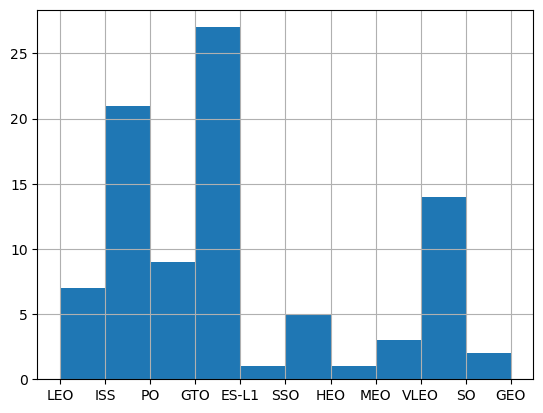

In [292]:
data['Orbit'].hist()

<br>

#### 🚀 Launch Site : Where the journey begins
The **LaunchSite** represents the location where the launch is triggered. 
We want to see if the location affects the landing success of the Falcon 9.
<br>
<br>

In [293]:
# Counting how many launches happened at each site
data['LaunchSite'].value_counts()

LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64

In [294]:
# Comparing Success (1) vs Failure (0) for each Launch Site
pd.crosstab(data['LaunchSite'], data['Class'])

Class,0,1
LaunchSite,,
CCAFS SLC 40,22,33
KSC LC 39A,5,17
VAFB SLC 4E,3,10


<br>

### 📊 Launch Site Success Findings

**CCAFS SLC 40** has hosted the most missions (55).

**KSC LC 39A** seems to be the most reliable site, with 17 successes out of 22 total missions.

While CCAFS is the primary site, it also carries the highest number of failures. This proves that the LaunchSite is a key factor in our landing predictions.
<br><br>

### ♻️ Reused Booster Analysis
The **Reused** column indicates if the first stage has been used in a previous launch.

<br> 

In [295]:
# Check reused boosters in successful launches
data_success['Reused'].value_counts()

Reused
False    31
True     29
Name: count, dtype: int64

In [296]:
# Check reused boosters in failed launches
data_fail['Reused'].value_counts()

Reused
False    22
True      8
Name: count, dtype: int64


<br>
<br>

We have **29** successful launches with **reused boosters** compared to **31** with **brand-new ones**. Reusing works!
 **Brand-new boosters** (False) failed **22** times, while **reused boosters** (True) failed only **8** times. 
 This data suggests that a "flight-proven" booster is actually more reliable than a brand-new one for a launch.
 <br><br>

### 🧇 GridFins Deployment Analysis
**GridFins** are small wing-like structures used to steer the booster during its return to Earth.

<br>

In [297]:
data_success['GridFins'].value_counts()

GridFins
True     58
False     2
Name: count, dtype: int64

In [298]:
data_fail['GridFins'].value_counts()

GridFins
False    18
True     12
Name: count, dtype: int64

<br>

In **58** out of **60** successful missions, GridFins were deployed. 
 When GridFins were not used (False), we see a high number of failures (**18**).
This data confirms that GridFins are one of the most important technical features for a successful launch landing.


### ⚖️ Payload Mass Analysis

In this section, we examine the **PayloadMass** (the weight of the cargo) to see how it affects the outcome of a launch. 

In [299]:
data_success['PayloadMass'].value_counts()

PayloadMass
15400.000000    9
9600.000000     6
6104.959412     3
15600.000000    2
2034.000000     1
3136.000000     1
3100.000000     1
4696.000000     1
2257.000000     1
2296.000000     1
570.000000      1
1316.000000     1
5300.000000     1
2490.000000     1
4600.000000     1
2708.000000     1
475.000000      1
4990.000000     1
3669.000000     1
2910.000000     1
2205.000000     1
4230.000000     1
350.000000      1
3750.000000     1
7076.000000     1
5800.000000     1
5200.000000     1
3700.000000     1
2800.000000     1
7060.000000     1
12259.000000    1
3000.000000     1
2482.000000     1
13620.000000    1
1425.000000     1
4000.000000     1
2227.700000     1
5000.000000     1
6800.000000     1
1977.000000     1
9525.000000     1
3880.000000     1
1600.000000     1
3681.000000     1
Name: count, dtype: int64

In [300]:
data_fail['PayloadMass'].value_counts()

PayloadMass
6104.959412     2
525.000000      1
677.000000      1
500.000000      1
3170.000000     1
3325.000000     1
4535.000000     1
4428.000000     1
2216.000000     1
2395.000000     1
1898.000000     1
4707.000000     1
2477.000000     1
553.000000      1
5271.000000     1
5500.000000     1
5600.000000     1
6070.000000     1
6761.000000     1
6092.000000     1
9600.000000     1
2760.000000     1
5383.850000     1
2410.000000     1
2573.000000     1
4400.000000     1
6500.000000     1
15400.000000    1
15600.000000    1
Name: count, dtype: int64

<BR>

Now we use histograms to see the distribution of weights for both successful and failed landings.

* **Green Chart:** Success missions.

* **Red Chart:** Failed missions.

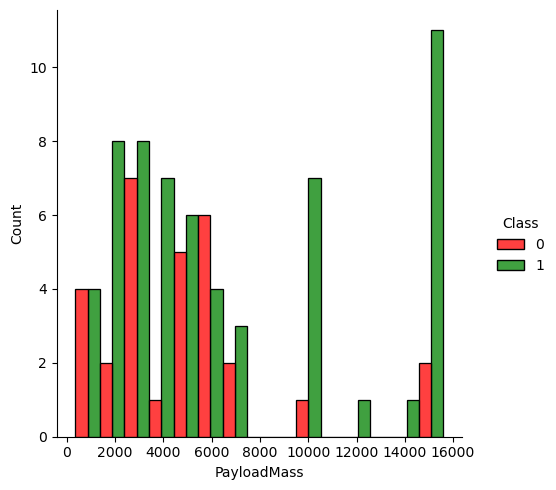

In [301]:
sns.displot(data=data, x='PayloadMass', hue='Class', palette={0: "red", 1: "green"}, bins=15, multiple='dodge')


### 📊 Side-by-Side Payload Mass Analysis
This chart allows us to see the exact count of Successes and Failures side-by-side for each weight range.

* **Zero Failures at High Weights :** At the far right of the chart (heavy payloads), we see only green bars. This indicates that Falcon 9 is exceptionally reliable when carrying heavy cargo, with a 100% success rate in this dataset.
* **The Competition Zone :** In the lower and middle ranges (under 10,000 kg), red and green bars appear together. This side-by-side comparison shows that landings are less certain at these weights, with failures occurring frequently alongside successes.

### 🚀 Booster Version Check
We looked at the **BoosterVersion** column to see if we have different types of rockets.


In [302]:
data['BoosterVersion']

0     Falcon 9
1     Falcon 9
2     Falcon 9
3     Falcon 9
4     Falcon 9
        ...   
85    Falcon 9
86    Falcon 9
87    Falcon 9
88    Falcon 9
89    Falcon 9
Name: BoosterVersion, Length: 90, dtype: object

In [303]:
# Checking for unique rocket versions in the dataset
data['BoosterVersion'].unique()

array(['Falcon 9'], dtype=object)


* **The Result:** Every single mission in our dataset used the **Falcon 9**. 
Since there is only one unique value, this column won't help us distinguish between a success or a failure. It's a "constant" value for all 90 rows.

In [304]:
# Checking unique values for FlightNumber
data['FlightNumber'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90])

In [305]:
# Checking unique values for Date
data['Date'].unique()

array(['6/4/2010', '5/22/2012', '3/1/2013', '9/29/2013', '12/3/2013',
       '1/6/2014', '4/18/2014', '7/14/2014', '8/5/2014', '9/7/2014',
       '9/21/2014', '1/10/2015', '2/11/2015', '4/14/2015', '4/27/2015',
       '6/28/2015', '12/22/2015', '1/17/2016', '3/4/2016', '4/8/2016',
       '5/6/2016', '5/27/2016', '7/18/2016', '8/14/2016', '9/1/2016',
       '1/14/2017', '2/19/2017', '3/16/2017', '3/30/2017', '5/1/2017',
       '5/15/2017', '6/3/2017', '6/23/2017', '6/25/2017', '7/5/2017',
       '8/14/2017', '8/24/2017', '9/7/2017', '10/9/2017', '10/11/2017',
       '10/30/2017', '12/15/2017', '12/23/2017', '1/8/2018', '1/31/2018',
       '3/6/2018', '3/30/2018', '4/2/2018', '4/18/2018', '5/11/2018',
       '6/4/2018', '6/29/2018', '7/22/2018', '7/25/2018', '8/7/2018',
       '9/10/2018', '10/8/2018', '11/15/2018', '12/3/2018', '12/5/2018',
       '12/23/2018', '1/11/2019', '3/2/2019', '5/4/2019', '5/24/2019',
       '6/12/2019', '7/25/2019', '8/6/2019', '11/11/2019', '12/5/2019',
     

<br>

### 🗑️ Data Cleaning :
After examining our data, we found that some columns don't provide useful patterns for our prediction model. To keep things simple and avoid "overfitting" , we are removing the following :

* **BoosterVersion :** This is redundant because every single entry in our list is a "Falcon 9."
* **FlightNumber & Date :** These act more like unique IDs or timestamps. They don't give us a repeatable reason why a landing succeeds or fails.
* **Longitude & Latitude :** These are just the GPS coordinates of the launch sites. Since we already have the site names, these numbers are extra noise.

**The Plan :** By dropping these columns, we make the dataset more efficient. The model will now focus only on the technical features that truly impact the launch outcome.

<br>

In [306]:
# Dropping the unnecessary columns 
data = data.drop(['FlightNumber', 'Date', 'BoosterVersion', 'Longitude', 'Latitude'], axis=1)

In [307]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PayloadMass  90 non-null     float64
 1   Orbit        90 non-null     object 
 2   LaunchSite   90 non-null     object 
 3   Outcome      90 non-null     object 
 4   Flights      90 non-null     int64  
 5   GridFins     90 non-null     bool   
 6   Reused       90 non-null     bool   
 7   Legs         90 non-null     bool   
 8   LandingPad   64 non-null     object 
 9   Block        90 non-null     int64  
 10  ReusedCount  90 non-null     int64  
 11  Serial       90 non-null     object 
 12  Class        90 non-null     int64  
dtypes: bool(3), float64(1), int64(4), object(5)
memory usage: 7.4+ KB


<br>

In the **LandingPad** column, we have some missing values. Usually, people delete these rows, but we don't want to lose important data!.

When we turn these names into numbers (Dummy Variables), if a row has a missing LandingPad, the computer will just put a  **0**  in all the new LandingPad columns.
So We keep all our rows (the whole 90 missions), and the computer understands that for these specific missions, no specific landing pad was used. 

<br>

### Creating "Dummy" variables (Turning text to 0 and 1)


 Turning Words into Numbers :
Computers are like calculators; they are great with numbers but they don't understand words like "Orbit" or "LaunchSite." 

* **The Goal :** We need to convert our text columns to 0s and 1s.
* **How it works :** If a rocket goes to "GTO," we put a 1 in the GTO column and 0 in all other orbit columns. This way, the computer can finally read our data.

<br>

In [308]:
data_dummy = pd.get_dummies(data[['Orbit', 'LaunchSite', 'Outcome', 'LandingPad', 'Serial']]).astype(int)

In [309]:
data_dummy.head()

,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,Orbit_LEO,Orbit_MEO,Orbit_PO,Orbit_SO,Orbit_SSO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<br>

We converted our categorical data (words) into dummy variables (numbers).
We are now using 0s and 1s to tell the computer exactly what happened in each mission.

## 🏗️ Preparing the Full Dataset
In this step, we are doing two things:
1. **Converting Booleans :** Changing "True/False" columns into 1s and 0s.
2. **Merging Everything :** Dropping the old text columns and "gluing" our new dummy variables to the rest of the data.(concatenating our two datasets, data and data_dummy)

**Goal :** Create a single table where every single piece of information is a number.

In [310]:
# Convert True/False to 1/0
data['GridFins'] = data['GridFins'].astype(int)
data['Reused'] = data['Reused'].astype(int)
data['Legs'] = data['Legs'].astype(int)

# Previewing the conversion for a few rows
data[['GridFins', 'Legs', 'Reused']][10:15]

,GridFins,Legs,Reused
10,0,0,0
11,1,1,0
12,1,1,0
13,1,1,0
14,0,0,0


In [311]:
# Remove the original text columns, because we don't need them anymore.
data = data.drop(['Orbit', 'LaunchSite', 'Outcome', 'LandingPad', 'Serial'], axis=1)

# Glue the numerical data and dummy variables together
data = pd.concat([data, data_dummy], axis=1)

data.head(5)

,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Class,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,6104.959412,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,525.000000,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,677.000000,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,500.000000,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,3170.000000,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


<br>

* By dropping the original columns and adding `data_dummy`, we replaced names with numbers.
* Using `pd.concat` acted like a strong glue, bringing the "PayloadMass" and other tech specs back together with the "Orbits" and "Serials".
* Now, every value in our `data` table is a number.

<br>

In [312]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 88 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   PayloadMass                          90 non-null     float64
 1   Flights                              90 non-null     int64  
 2   GridFins                             90 non-null     int64  
 3   Reused                               90 non-null     int64  
 4   Legs                                 90 non-null     int64  
 5   Block                                90 non-null     int64  
 6   ReusedCount                          90 non-null     int64  
 7   Class                                90 non-null     int64  
 8   Orbit_ES-L1                          90 non-null     int64  
 9   Orbit_GEO                            90 non-null     int64  
 10  Orbit_GTO                            90 non-null     int64  
 11  Orbit_HEO                         

<br>

## 💾 Exporting the Processed Dataset
We have finished the Data Engineering and Feature Engineering phases. To maintain a clean workflow, we are exporting the final transformed dataset. This file will be our primary input for the Machine Learning models in the next stage.

In [313]:
# Saving the final dataset to your project folder
data.to_csv("D:/project/preprocessed_data.csv", index=False)

<br>

## 🤖 Machine Learning: Predicting Success Rate
With the data cleaned and prepared, we are now ready to train our Machine Learning models to predict landing success.

## 🎯 Separating Features (X) and Target (Y)
Before we train our model, we need to split our table into two parts:
* **X :** All the technical information about the rocket.
* **Y :** Whether the landing was successful or not (the `Class` column).

In [314]:
# Separating the features and the answer
x = data.drop('Class', axis=1)
y = data['Class']

# Creating the Scaler
transform = preprocessing.StandardScaler()

# Squishing the numbers to be the same size
x_scaled = transform.fit_transform(x)

# Turning it back into a nice table with names
col = x.columns
x = pd.DataFrame(x_scaled, columns=col)

# the first 5 rows
x.head(5)

,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,4.759999e-11,-0.653913,-1.870829,-0.835532,-1.933091,-1.575895,-0.97344,-0.106,-0.106,-0.654654,...,-0.215666,-0.267261,-0.106,-0.242536,-0.106,-0.215666,-0.185695,-0.215666,-0.185695,-0.106
1,-1.195232e+00,-0.653913,-1.870829,-0.835532,-1.933091,-1.575895,-0.97344,-0.106,-0.106,-0.654654,...,-0.215666,-0.267261,-0.106,-0.242536,-0.106,-0.215666,-0.185695,-0.215666,-0.185695,-0.106
2,-1.162673e+00,-0.653913,-1.870829,-0.835532,-1.933091,-1.575895,-0.97344,-0.106,-0.106,-0.654654,...,-0.215666,-0.267261,-0.106,-0.242536,-0.106,-0.215666,-0.185695,-0.215666,-0.185695,-0.106
3,-1.200587e+00,-0.653913,-1.870829,-0.835532,-1.933091,-1.575895,-0.97344,-0.106,-0.106,-0.654654,...,-0.215666,-0.267261,-0.106,-0.242536,-0.106,-0.215666,-0.185695,-0.215666,-0.185695,-0.106
4,-6.286706e-01,-0.653913,-1.870829,-0.835532,-1.933091,-1.575895,-0.97344,-0.106,-0.106,1.527525,...,-0.215666,-0.267261,-0.106,-0.242536,-0.106,-0.215666,-0.185695,-0.215666,-0.185695,-0.106


### 💡 Why did we do this?

* **Training the Brain :** Imagine you are studying for a test. You have the Questions **(X)** and the Correct Answers **(Y)**.

  To learn, you need to see them separately so you can try to guess the answer yourself.

* **Compatibility :** Converting `Y` to a NumPy array makes it much faster and easier for Machine Learning libraries like Scikit-Learn to read.

* **Result :** Now we have a clean set of inputs (X) and a clear target (Y) to aim for.

<br>

## ✂️ Splitting the Data : Training vs. Testing
To build a reliable model, we shouldn't show all our data to the computer at once. We need to save some missions for a "final exam" to see if the model actually learned something or just memorized the answers.
This time, we are reserving **30%** of the data for testing to ensure our model is truly reliable.

* **Training Set (70%) :** Where the model learns the patterns.
* **Test Set (30%) :** The "hidden" data used for the final evaluation.


<br>


In [315]:
# Splitting the data with a 30% test size
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.30, random_state=101)

#### 📝 Creating a Leaderboard
To find the best model, we need a place to store our results. We are creating two empty lists to keep track of every method we try and its final score.

In [316]:
# Defining empty lists to store model names and their accuracies
accuracy = []
method = []


# 🚀 Starting the Prediction Phase
Now that our data is preprocessed and standardized, we will apply various Machine Learning algorithms to predict the success of SpaceX Falcon 9 landings.

## ⚖️ Model 1 : Logistic Regression
We start our prediction journey with **Logistic Regression**, which is a classification algorithm used to predict the probability of a "Yes" or "No" outcome.
* **How it works :** It looks at all our features (like Payload Mass and Orbit) and calculates the chance of a successful landing between 0 and 1.
* **The Decision :** If the probability is higher than 0.5 (50%), the model predicts a "Success" (1). Otherwise, it predicts a "Failure" (0).
 
<br>

### 🛠️ Hyperparameter Selection & Tuning
To ensure our **Logistic Regression** model is both accurate and reliable, we chose the following hyperparameters for tuning:

* **C (Regularization Strength) :** We tested values [0.01, 0.1, 1] to find the optimal balance. This prevents the model from being too simple (underfitting) or too complex (overfitting).
* **Penalty (L2) :** We applied **Ridge Regularization** (L2) to penalize overly large coefficients, which helps the model generalize better to new, unseen data.
* **Solver (lbfgs) :** The 'lbfgs' algorithm was selected as our optimizer. It is highly efficient for multiclass problems and handles L2 penalties with excellent stability.

In [317]:
from sklearn import set_config
set_config(display='text')

In [318]:
# Setting the parameters to test
parameters ={"C":[0.01,0.1,1], 'penalty':['l2'], 'solver':['lbfgs']}

# Initializing the model
lr = LogisticRegression()

# Finding the best version of the model using 10-fold cross-validation
logreg_cv = GridSearchCV(lr, parameters, cv=10)
logreg_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

In [319]:
# Displaying the best settings again
print(logreg_cv.best_params_)

{'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}


In [320]:
# Making predictions on the test data
yhat = logreg_cv.predict(x_test)

In [321]:
# Storing the results in our leaderboard
accuracy.append(accuracy_score(y_test, yhat))
method.append("Logistic regression")

# Showing the final score
print("LR Test Accuracy :", accuracy_score(y_test, yhat))

LR Test Accuracy : 0.8888888888888888


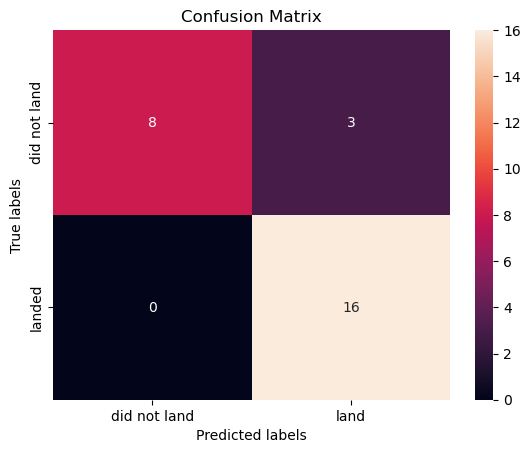

In [322]:
# Plotting the "Success and Failure" map
plot_confusion_matrix(y_test, yhat ) 


<br>

### 📊 Final Evaluation of Logistic Regression

Now that our model is trained, we test it on the hidden data (`x_test`) to see how it performs. We also use a **Confusion Matrix** to see the balance of correct and incorrect guesses.

### 📝 Results Table
| Metric | Result | What it means |
| :--- | :---: | :--- |
| **Accuracy Score** | **~88%** | The model was right in most missions. |
| **True Positives (TP)** | **16** | Correctly predicted missions that **Succeeded**. |
| **True Negatives (TN)** | **8** | Correctly predicted missions that **Failed**. |
| **False Positives (FP)** | **3** | Guessed "Success," but it was actually a **Failure**. |
| **False Negatives (FN)** | **0** | Never missed a single real **Success**. |

---


* It was correct about **88%** of the time.
* The best part is that it never missed a real successful landing (**FN=0**).
* If a rocket is going to land safely, our model is guaranteed to know it!
* It only made 3 mistakes where it thought the rocket would land, but it actually didn't (**FP=3**).

<br>

## 🏘️ Model 2: K-Nearest Neighbors (KNN)
Our next model is **KNN**. It’s like the "Friendly Neighbor" algorithm.

* **How it works :** To predict if a rocket will land safely, the model looks at the **"K"** most similar launches from the past (its neighbors).
* **The Decision :** If most of those similar launches were successful, the model predicts "Success!"
* **The "K" :** We test different numbers of neighbors ( from 1 to 10 ) to see which group gives us the best answer.

<br>

In [323]:
# Creating the KNN object
knn = KNeighborsClassifier()

# Defining the parameters to test (The "Crayons" in our box)
parameters = {
    'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
    'p': [1, 2]
}


# Creating GridSearchCV to find the best settings
knn_cv = GridSearchCV(knn, parameters, cv=5)

# 4 Training the model
knn_cv.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]})

In [324]:
# Displaying the best neighbor settings
print(knn_cv.best_params_)

{'algorithm': 'auto', 'n_neighbors': 2, 'p': 1}


In [325]:
# Making predictions (naming it yhat_2 to be unique)
yhat_2 = knn_cv.predict(x_test)

# Adding the results to our leaderboard
accuracy.append(accuracy_score(y_test, yhat_2))
method.append("k Nearest Neighbors")


# Printing the score and plotting the matrix
print("KNN Test Accuracy :", accuracy_score(y_test, yhat_2))

KNN Test Accuracy : 0.8518518518518519


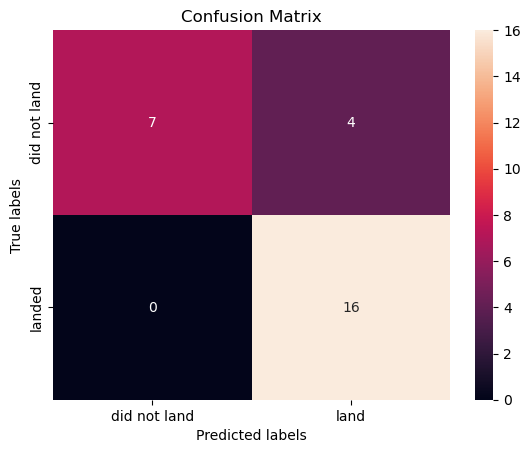

In [326]:
plot_confusion_matrix(y_test, yhat_2)

<br>

### 📊 Final Evaluation of K-Nearest Neighbors (KNN)
Now that our KNN model is trained with the best neighbors, we test it on the hidden data (`x_test`) to see how it performs in the real world. We use a **Confusion Matrix** to visualize the balance of correct and incorrect guesses.

### 📝 Results Table

| Metric | Value | Description |
| :--- | :---: | :--- |
| **TP** (True Positive) | **16** | Correctly predicted a **Successful** landing. |
| **TN** (True Negative) | **7** | Correctly predicted a **Failed** landing. |
| **FP** (False Positive) | **4** | Predicted **Success**, but the mission actually **Failed**. |
| **FN** (False Negative) | **0** | Predicted **Failure**, but the mission actually **Succeeded**. |

---




* The neighbors correctly guessed 16 times that the rocket would land safely.
* They also correctly identified 7 times that the mission would fail.
* In 4 missions, the neighbors thought the rocket would land, but it actually failed.
* The neighbors never missed a real successful landing. The model was very effective at identifying successful landings.
*  With an overall accuracy of about **85%**, KNN is a very smart "neighbor" for this project. 
Since it has **0** False Negatives, it is very reliable for knowing when a landing will be successful!

<br>

## 🌳 Model 3 : Decision Tree
Now we move to our third model : the **Decision Tree**. 

* **How it works :** Think of it like a game of **"20 Questions."** The model asks a series of questions about the data (like "Is the payload heavy?" or "Is the launch site near the equator?").
* **The Path :** Depending on the answer (Yes or No), it follows a specific branch until it reaches the final "Leaf".
* **The Goal :** The "Leaf" gives us the final prediction: will the Falcon 9 land safely or not?
 
<br>

In [327]:
# Create the Decision Tree object
tree = DecisionTreeClassifier(random_state=101)

# Setting up the hyperparameters for the tree
parameters = {
    'criterion': ['gini', 'entropy'],
    'splitter': ['best', 'random'],
    'max_depth': [2*n for n in range(1,10)],
    'max_features': ['sqrt'],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10]
}

# Create the GridSearchCV object
tree_cv = GridSearchCV(tree, parameters, cv=10)

# Training the model
tree_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=101),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [328]:
# Displaying the best tree settings
print(tree_cv.best_params_)

{'criterion': 'entropy', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}


In [329]:
# Making predictions (naming it yhat_3 to be unique)
yhat_3 = tree_cv.predict(x_test)

# Adding the results to our leaderboard
accuracy.append(accuracy_score(y_test, yhat_3))
method.append("Decision Tree")

# Printing the score and plotting the matrix
print("Decision Tree Test Accuracy :", accuracy_score(y_test, yhat_3))

Decision Tree Test Accuracy : 0.8888888888888888


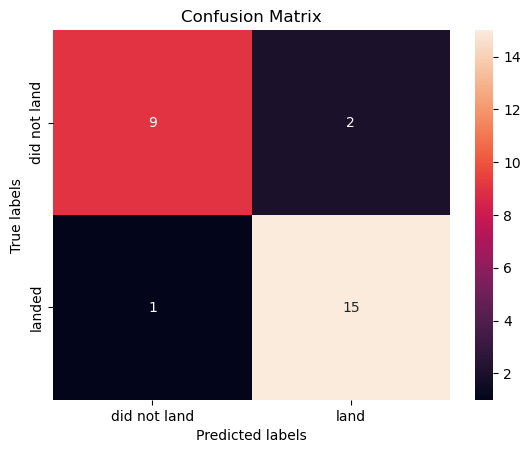

In [330]:
plot_confusion_matrix(y_test, yhat_3)

<br>

### 📊 Final Evaluation of Decision Tree
Now that our Decision Tree model is trained with the best parameters, we test it on the hidden data (`x_test`) to see how it performs in the real world. We use a **Confusion Matrix** to visualize the balance of correct and incorrect guesses.

### 📝 Results Table

| Metric | Value | Description |
| :--- | :---: | :--- |
| **TP** (True Positive) | **15** | Correctly predicted a **Successful** landing. |
| **TN** (True Negative) | **9** | Correctly predicted a **Failed** landing. |
| **FP** (False Positive) | **2** | Predicted **Success**, but the mission actually **Failed**. |
| **FN** (False Negative) | **1** | Predicted **Failure**, but the mission actually **Succeeded**. |

---


* The tree correctly guessed 15 times that the rocket would land safely.
* It also correctly identified 9 failures. (It's actually better at this than KNN and LR!)
* Only 2 times it thought the rocket would land when it actually failed.
* It missed only 1 real success, thinking it would fail.
* With an overall accuracy of about **89%**, this Decision Tree is very smart! It is especially good at catching those tricky failed landings.

<br>

## 🛡️ Model 4 : Support Vector Machine (SVM)
Our final model is **SVM**. It is like a very strict "Boundary Maker."

* **How it works :** Imagine we have two groups of points (Land vs. Did Not Land). SVM tries to draw the widest possible "road" or boundary between them so they stay separated.
* **The Goal :** It doesn't just want to separate them; it wants the biggest safety margin (gap) possible.
* **Hyperparameters :**
* **Kernel :** Decides if the boundary line should be straight or curvy.
* **C :** Decides how strict the model should be about mistakes.

<br>

In [331]:
# Create the SVM object (SVC)
svm = SVC()

# Setting up the hyperparameters
parameters = {
    'kernel': ('linear', 'rbf', 'poly', 'sigmoid'), 
    'C': (0.5, 1, 1.5)
}

# Create GridSearchCV to find the best boundary
svm_cv = GridSearchCV(svm, parameters, cv=10)

# Training the model
svm_cv.fit(x_train, y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': (0.5, 1, 1.5),
                         'kernel': ('linear', 'rbf', 'poly', 'sigmoid')})

In [332]:
# Making predictions (naming it yhat_4 to be unique)
yhat_4 = svm_cv.predict(x_test)

# Adding the results to our leaderboard
accuracy.append(accuracy_score(y_test, yhat_4))
method.append("Support Vector Machine")

# Printing the score and plotting the matrix
print("svm Test Accuracy :", accuracy_score(y_test, yhat_4))

svm Test Accuracy : 0.8888888888888888


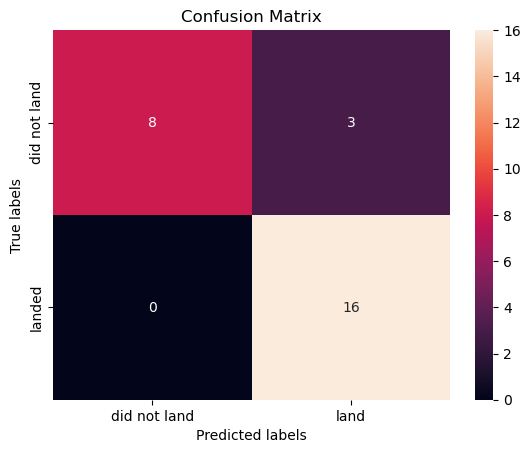

In [333]:
plot_confusion_matrix(y_test, yhat_4)

<br>

### 📊 Final Evaluation of Support Vector Machine (SVM)

Now that our SVM model is trained with the best parameters (C and Kernel), we test it on the hidden data (`x_test`) to see how it performs. We use a **Confusion Matrix** to visualize the balance of correct and incorrect guesses.

### 📝 Results Table

| Metric | Value | Description |
| :--- | :---: | :--- |
| **TP** (True Positive) | **16** | Correctly predicted a **Successful** landing. |
| **TN** (True Negative) | **8** | Correctly predicted a **Failed** landing. |
| **FP** (False Positive) | **3** | Predicted **Success**, but the mission actually **Failed**. |
| **FN** (False Negative) | **0** | Predicted **Failure**, but the mission actually **Succeeded**. |

---

### 📝 Results Analysis (English)
* The model correctly guessed 16 times that the rocket would land safely.
* It also correctly identified 8 times that the mission would fail.
* In 3 missions, the SVM thought the rocket would land, but it actually failed.
* It never missed a real successful landing. If there was a winner, SVM spotted it!
* With an overall accuracy of about **88%**, SVM is smart and reliable.

<br>

## 🏁 Final Evaluation : Comparison of All Models
After building and testing four different Machine Learning models, we now put their results side-by-side. 
Our goal is to see which model was the most accurate in predicting whether a SpaceX Falcon 9 rocket would land safely.

### 📊 Comparison Summary :
1. **Logistic Regression (LR) :** Our first model, set a strong baseline with **88%** accuracy.
2. **K-Nearest Neighbors (KNN) :** The "Friendly Neighbor" model performed slightly worse than LR, with **85%**.
3. **Decision Tree :** This model was more balanced in identifying failures! It scored slightly higher (**~89%**) by being better at predicting failures.
4. **Support Vector Machine (SVM) :** Our final model, which returned to the consistent **88%** accuracy mark.

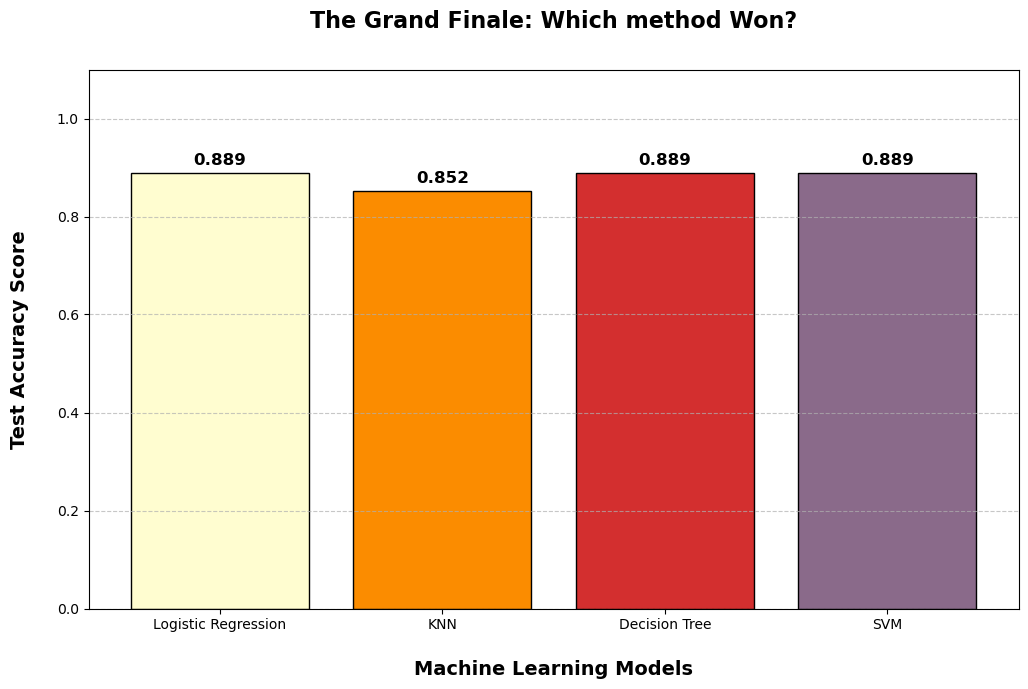

In [334]:
# Putting the results in a clear list 
methods = ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM']

# Creating the Bar Chart
plt.figure(figsize=(12, 7))
bars = plt.bar(methods, accuracy, color=['#fffdd0', '#fb8c00' , '#d32f2f','#8a6a8a'], edgecolor='black')

# Adding the exact score on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.3f}', 
             ha='center', va='bottom', fontsize=12, fontweight='bold')

#  Decorating the plot
plt.xlabel('Machine Learning Models', fontsize=14, fontweight='bold' , labelpad=20)
plt.ylabel('Test Accuracy Score', fontsize=14, fontweight='bold' , labelpad=20 )
plt.title('The Grand Finale: Which method Won?', fontsize=16, fontweight='bold', pad=30)
plt.ylim(0, 1.1) # Gives some space at the top
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Show the final result
plt.show()

<br>

The bar chart reveals that **Logistic Regression, Decision Tree, and SVM** achieved an identical accuracy score of approximately **88.9%**. 

**Why is this important?**
* It shows that our features (like payload mass, orbit, etc.) are very strong predictors.
* Based on accuracy alone, no single model is clearly better than the others.
* Overall, the models showed similar performance, with Logistic Regression, SVM, and Decision Tree achieving nearly the same accuracy.

<br>

### 🏁 Final Winner Selection
After testing our models, we want to see which one performed best during the training phase (Cross-Validation). 
The code below collects the `best_score_` from each model and automatically identifies our "Optimal Model".

In [335]:
# Collect training scores
best_scores = {
    'Logistic Regression': logreg_cv.best_score_,
    'K-Nearest Neighbors': knn_cv.best_score_,
      'Decision Tree': tree_cv.best_score_,
    'Support Vector Machine': svm_cv.best_score_
  
    
}

# Find and print the winner
best_model = max(best_scores, key=best_scores.get)
best_score = best_scores[best_model]

print(f"The best model is {best_model} with a score of {best_score}")

The best model is Support Vector Machine with a score of 0.9380952380952381


<br>

### 📈 ROC (Receiver Operating Characteristic) Curve :

In this section, we use the **ROC Curve** to compare our four models. This chart helps us see how well each robot can distinguish between a "Successful Landing" and a "Failure." The closer the curve is to the top-left corner, the better the model is at making correct predictions.

<br>


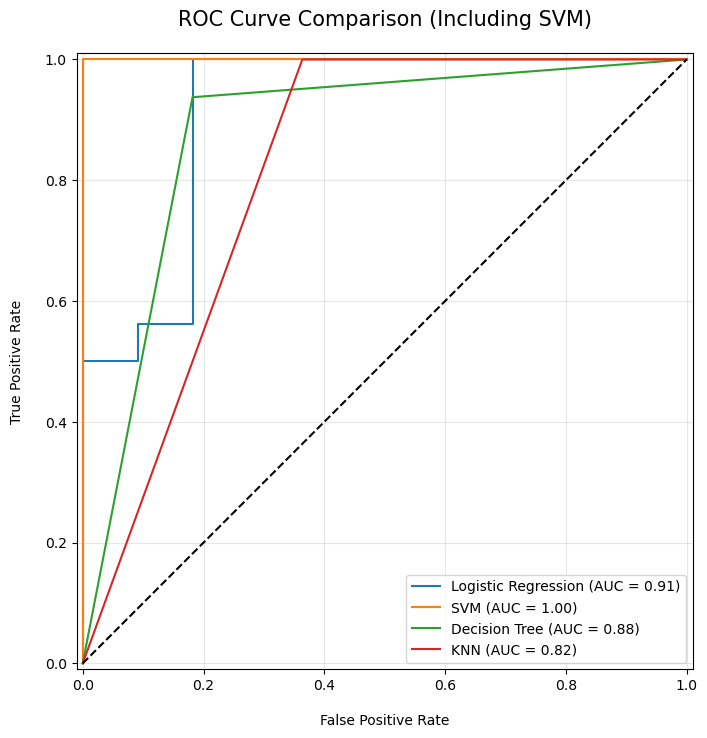

In [336]:
models = {
    'Logistic Regression': logreg_cv,
    'SVM': svm_cv,
    'Decision Tree': tree_cv,
    'KNN': knn_cv
}

# Plotting everything
plt.figure(figsize=(10, 8))

# Loop through each model and plot the ROC curve on the same plot
for model_name, model in models.items():
    RocCurveDisplay.from_estimator(model, x_test, y_test, name=model_name, ax=plt.gca())

# Add baseline and decorations
plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.title('ROC Curve Comparison (Including SVM)', fontsize=15, pad=20)
plt.xlabel('False Positive Rate', labelpad=15)
plt.ylabel('True Positive Rate', labelpad=15)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Show the plot
plt.show()

<br>

By analyzing the ROC curves for Logistic Regression, SVM, Decision Tree, and KNN, we can conclude :
* **High Performance :** All four models show curves that are very close to the top-left corner, indicating high predictive power.
* **Model Similarity :** The curves are nearly overlapping, which confirms that most models achieved similarly high performance, although KNN performed slightly lower than the others.
* **Reliability :** Since all models stay far above the dashed black line, we can trust that our machine learning approach is much smarter than random guessing.

# 📊 Comparative Analysis of Model Accuracies

To gain a deeper understanding of how each model performs, we generate a **Classification Report** for all four algorithms (Logistic Regression, KNN, Decision Tree and SVM). This report provides key metrics such as **Precision, Recall, and F1-Score**, allowing us to see not just the overall accuracy, but also how well each model identifies successful landings versus failures.

In [337]:
# Logistic Regression
print("--- Logistic Regression Report ---")
yhat_logreg = logreg_cv.predict(x_test)
print(classification_report(y_test, yhat_logreg))

#  K-Nearest Neighbors (KNN)
print("\n--- KNN Report ---")
yhat_knn = knn_cv.predict(x_test)
print(classification_report(y_test, yhat_knn))

# Decision Tree
print("\n--- Decision Tree Report ---")
yhat_tree = tree_cv.predict(x_test)
print(classification_report(y_test, yhat_tree))

# Support Vector Machine (SVM)
print("\n--- SVM Report ---")
yhat_svm = svm_cv.predict(x_test)
print(classification_report(y_test, yhat_svm))

--- Logistic Regression Report ---
              precision    recall  f1-score   support

           0       1.00      0.73      0.84        11
           1       0.84      1.00      0.91        16

    accuracy                           0.89        27
   macro avg       0.92      0.86      0.88        27
weighted avg       0.91      0.89      0.88        27


--- KNN Report ---
              precision    recall  f1-score   support

           0       1.00      0.64      0.78        11
           1       0.80      1.00      0.89        16

    accuracy                           0.85        27
   macro avg       0.90      0.82      0.83        27
weighted avg       0.88      0.85      0.84        27


--- Decision Tree Report ---
              precision    recall  f1-score   support

           0       0.90      0.82      0.86        11
           1       0.88      0.94      0.91        16

    accuracy                           0.89        27
   macro avg       0.89      0.88      0.88

<br>

### 📖 Key Evaluation Metrics Explained
* **Accuracy :** The "Overall Grade" — The percentage of total correct predictions out of all samples.
* **Precision :** The "Reliability Score" — How often is the model correct when it predicts a success?
* **Recall :** The "Detective Score" — How many of the total actual successes did the model manage to find?
* **F1-Score :** The "Balance Score" — A single grade that combines both Precision and Recall.
* **Support :** The "Sample Size" — The total number of records for each class in the test set.

### 📊 Final Model Performance Comparison

| Model | Accuracy | Precision (Avg) | Recall (Avg) | F1-Score (Avg) | **Recall Class 0 (Risk)** |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Logistic Regression** | 89% | 91% | 89% | 88% | 73% |
| **KNN** | 85% | 88% | 85% | 84% | 64% |
| **Decision Tree** | **89%** | 89% | **89%** | **89%** | **82%** |
| **SVM** | 89% | 91% | 89% | 88% | 73% |



> <br>

# 🏆 Final Model Comparison 
Based on the detailed classification reports for all four models, we can draw the following final conclusions:

#### 1. Performance Overview :
* **Logistic Regression, SVM, and Decision Tree** all achieved the highest overall accuracy of **89%** on the test dataset.
* **KNN** performed slightly lower with an accuracy of **85%**.

#### 2. Deep Dive into Metrics :
* **Logistic Regression & SVM :** These models were identical in performance. While they had perfect precision for failures (1.00), their **Recall** for Class 0 was only **0.73**, meaning they missed 27% of actual landing failures.
* **Decision Tree :** This model is our **Optimal Choice**. Although its accuracy is tied with others, it provides a more balanced performance with a **Recall** of **0.82** for Class 0. It is more reliable at identifying potential failures compared to the other models.

#### 3. Final Recommendation :
The **Decision Tree** model is recommended for SpaceX mission predictions. Its ability to better identify unsuccessful landings (Class 0) while maintaining high accuracy for successes makes it the most robust tool for risk assessment in this project.

In [338]:
# Saving our champion: The Decision Tree
pickle.dump(tree_cv, open("optimal_decision_tree.pkl", "wb"))

# Conclusion

In this project, we addressed the classification challenge of predicting the successful landing of the SpaceX Falcon 9 first stage. Following rigorous data preprocessing and feature engineering, we trained and evaluated several machine learning algorithms, including **Logistic Regression , SVM , Decision Tree , and KNN**.

While several models achieved an identical top accuracy of **89%**, accuracy alone was not enough, so class-wise metrics were also considered. The **Decision Tree** emerged as the optimal choice for this specific task. Its superior **Recall for unsuccessful landings (Class 0)** makes it the most reliable model for risk assessment in aerospace missions, where identifying potential failures is a top priority.

This project covers the entire journey from data analysis to selecting the best model, creating a reliable way to use facts for planning rocket missions.